# Control vs SDV: latent-variable causal models
Fit Case 2 (static) and Case 4 (dynamic) to paired BN18 ROI timeseries from fMRIPrep derivatives. Results are descriptive model outputs, not biological causal conclusions.

The current export lacks Subject015's control scan. `PAIRING = "intersection"` explicitly retains complete pairs and reports exclusions; use `"strict"` to require every exported subject in both states. Scan lengths may differ. All plot labels and coordinates come from the selected atlas.

## 1. Setup

In [7]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from causal_opt.fmri_data import (
    load_paired_tsv_states, data_summary, build_static_fmri_matrix,
)
from causal_opt.fmri import (
    latent_similarity, model_statistics, report_effective_latent_rank,
    save_result, top_matrix_changes,
)
from causal_opt.fmri_plotting import plot_anatomical_graph_difference
from causal_opt.fmri_reporting import plot_static_report, plot_dynamic_report, display_figures
from causal_opt.methods.static_latent import fit_static_latent
from causal_opt.methods.dynamic_latent import fit_dynamic_latent
import matplotlib.pyplot as plt

FMRI_ROOT = Path(os.getenv("FMRI_CONNECTIVITY_ROOT", ROOT.parent / "fmri_connectivity"))
TS_ROOT = FMRI_ROOT / "data" / "derivatives" / "r03_healthy" / "rois" / "BN18"
ATLAS_LABELS = FMRI_ROOT / "data" / "templates" / "ROIs" / "BN18_labels.json"
OUTPUT = ROOT / "results" / "fmri_notebook_bn18"
OUTPUT.mkdir(parents=True, exist_ok=True)
PAIRING = "intersection"
SEED, K, P, EDGE_THRESHOLD = 1, 2, 1, 0.3
SOLVER = dict(random_state=SEED, max_outer_iter=100, inner_max_iter=None, h_tol=1e-8)
STATIC = dict(k=K, lambda_w=0.1, lambda_latent=2., w_threshold=EDGE_THRESHOLD, **SOLVER)
DYNAMIC = dict(k=K, lambda_0=0.1, lambda_lag=0.05, lambda_latent=0.02,
               w0_threshold=EDGE_THRESHOLD, wlag_threshold=EDGE_THRESHOLD, **SOLVER)

## 2. Load paired BN18 data

In [8]:
control, sdv = load_paired_tsv_states(TS_ROOT, ATLAS_LABELS, pairing=PAIRING)
DISPLAY = control.roi_names
print(data_summary(control, "control"))
print(data_summary(sdv, "SDV"))
print("Paired subjects:", control.subject_ids)
print("ROIs:", DISPLAY)
X_control = build_static_fmri_matrix(control)
X_sdv = build_static_fmri_matrix(sdv)
print("Pooled matrices:", X_control.shape, X_sdv.shape)

{'state': 'control', 'subjects': 18, 'rois': 18, 'T_min': 168, 'T_median': 192.0, 'T_max': 194, 'pooled_rows': 3435}
{'state': 'SDV', 'subjects': 18, 'rois': 18, 'T_min': 168, 'T_median': 192.0, 'T_max': 197, 'pooled_rows': 3437}
Paired subjects: ('Subject002', 'Subject003', 'Subject004', 'Subject005', 'Subject006', 'Subject007', 'Subject008', 'Subject009', 'Subject010', 'Subject011', 'Subject012', 'Subject013', 'Subject014', 'Subject016', 'Subject017', 'Subject018', 'Subject019', 'Subject020')
ROIs: ('Cerebellum 1', 'Cerebellum 2', 'Cerebellum 3', 'Dorsal Anterior Cingulate Cortex', 'Dorsolateral Prefrontal Cortex', 'Inferior Frontal Gyrus', 'Left Insula', 'Medial Frontal Gyrus', 'Medial Prefrontal Cortex', 'Periaqueductal Gray 1', 'Periaqueductal Gray 2', 'Periaqueductal Gray 3', 'Pontine Micturition Center 1', 'Pontine Micturition Center 2', 'Right DLPFC Stimulation Target (F4)', 'Right Insula', 'SMA Stimulation Target', 'Thalamus')
Pooled matrices: (3435, 18) (3437, 18)


/home/ab126/projects/CausalOpt/src/causal_opt/fmri_data.py:228: UserWarning: Retaining 18 paired subjects; excluded control=(), SDV=('Subject015',) (opposite state missing).
  return pair_fmri_states(control, sdv, pairing=pairing)


## 3. Case 2: static latent-confounded model

In [9]:
static_control = fit_static_latent(X_control, **STATIC)
static_sdv = fit_static_latent(X_sdv, **STATIC)
for state, result in (("Control", static_control), ("SDV", static_sdv)):
    print(state, result.diagnostics)
    report_effective_latent_rank(result, state)
    print(model_statistics(result.W0, latent_similarity(result), result.diagnostics["h_thresholded"]))
save_result(OUTPUT / "static_control.npz", static_control, DISPLAY, DISPLAY, control.subject_ids)
save_result(OUTPUT / "static_sdv.npz", static_sdv, DISPLAY, DISPLAY, sdv.subject_ids)

Control {'objective': 300.578356709123, 'primal_objective': 300.56810113176545, 'fit_loss': 299.7150385111602, 'sparse_penalty': 0.8530626206052898, 'latent_penalty': 1.663954473479623e-19, 'h_raw': 8.959048614087806e-09, 'h_thresholded': 0.0, 'h': 0.0, 'rho': 100000000000000.0, 'alpha': 1592669.6656830772, 'outer_iterations': 9, 'total_inner_iterations': 1708, 'total_function_evaluations': 1819, 'optimizer_success': True, 'optimizer_messages': ['CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR

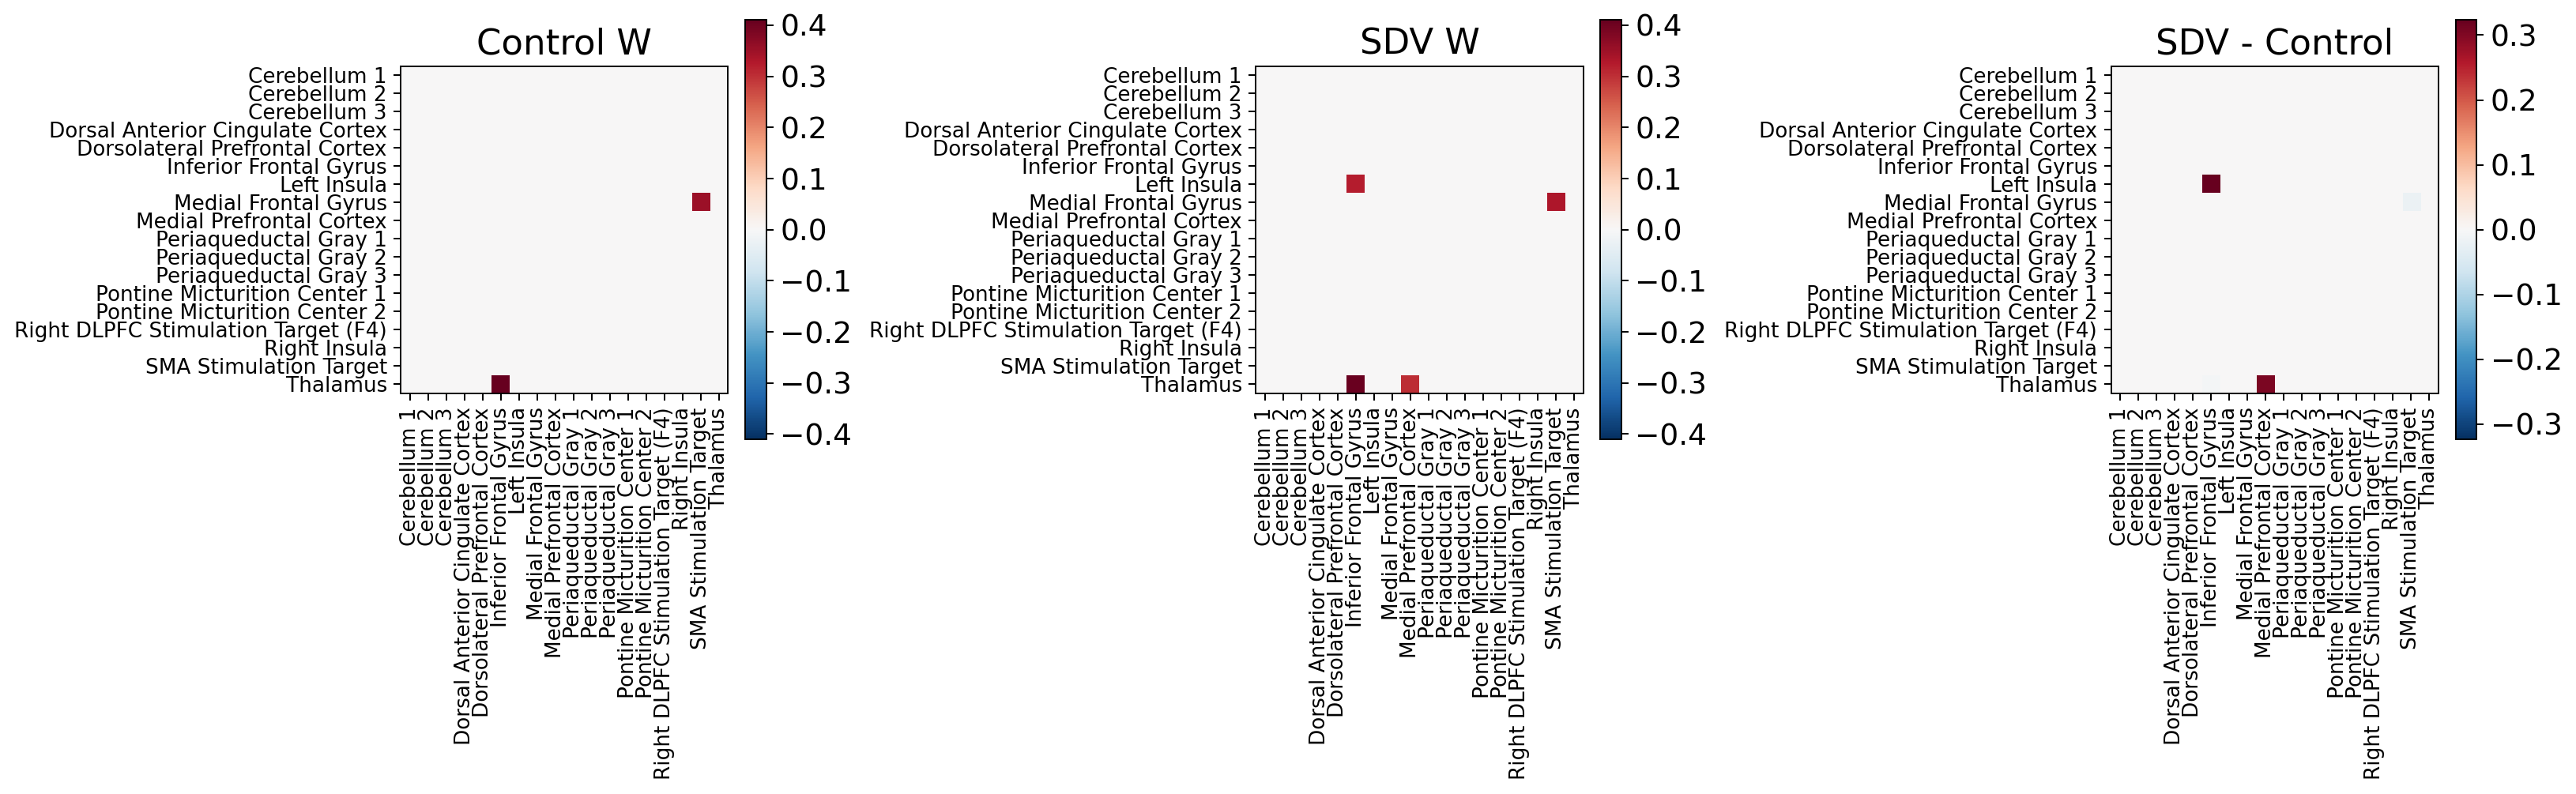

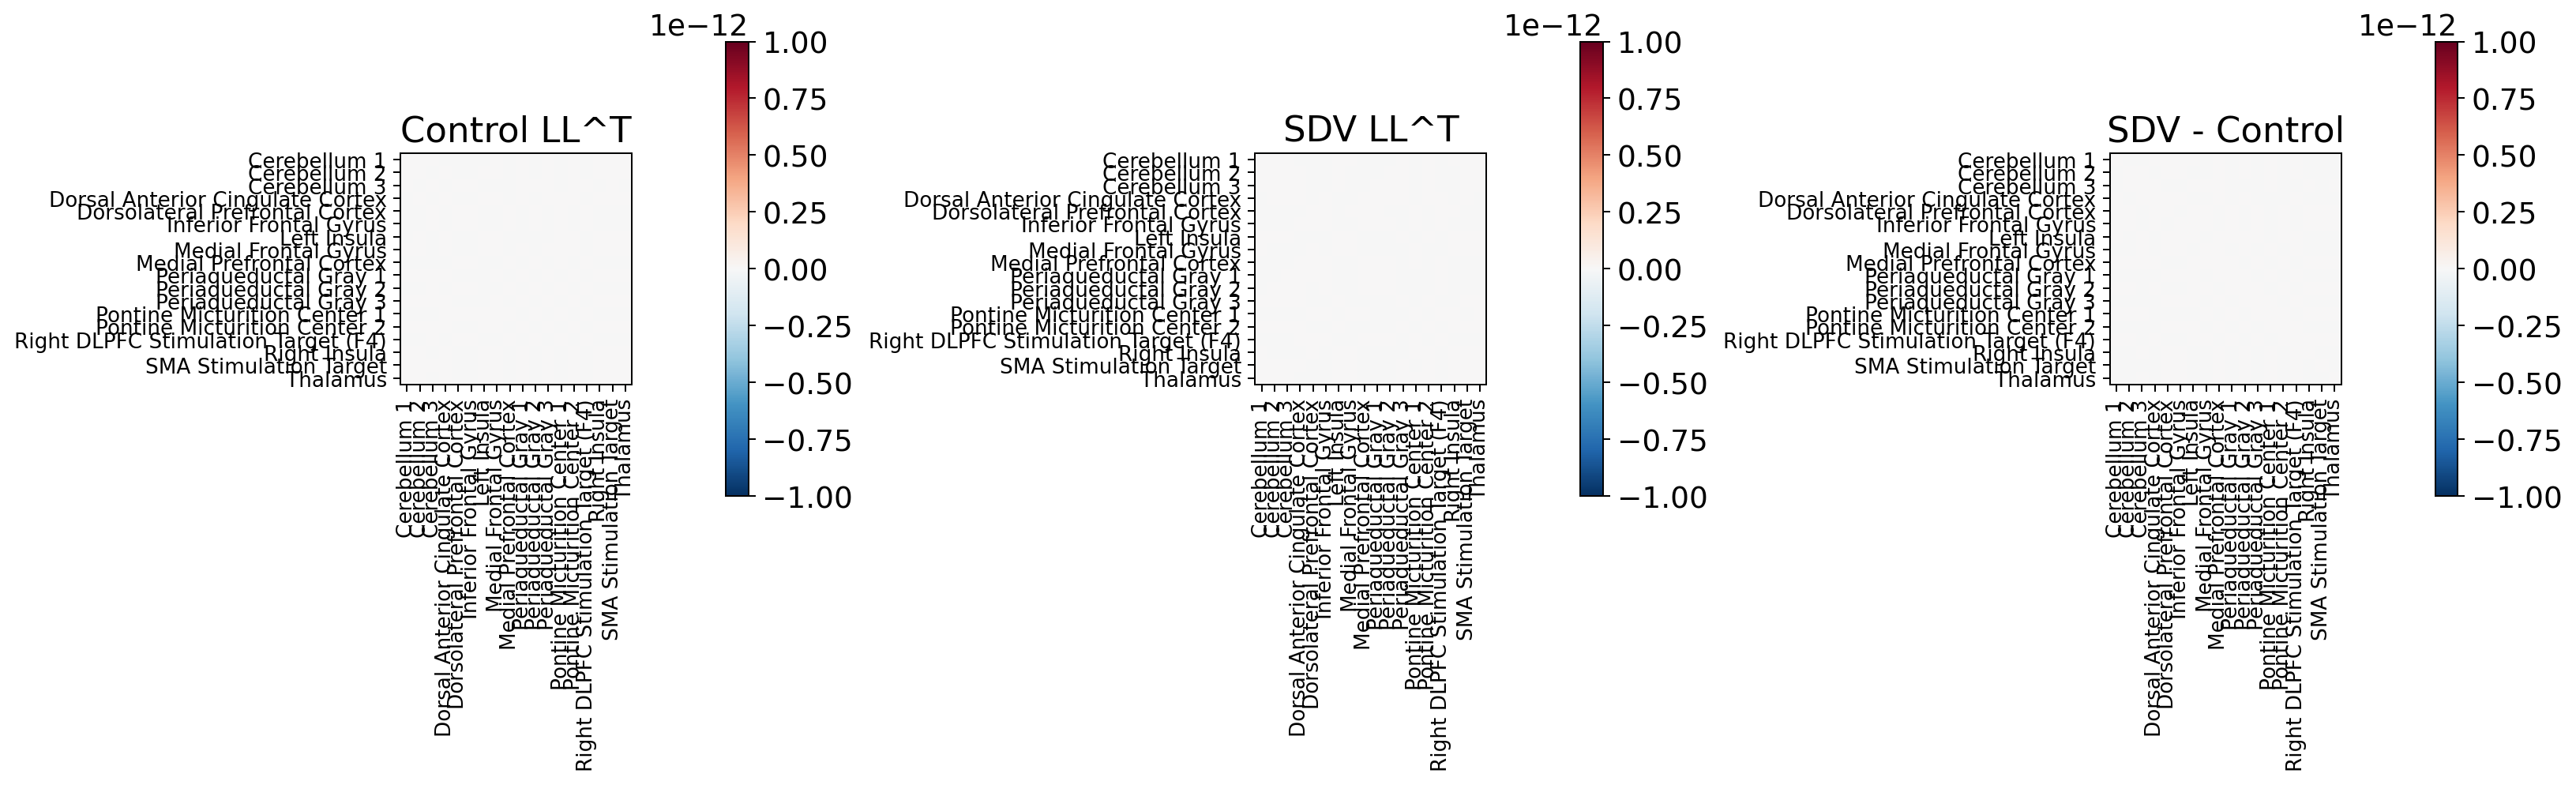

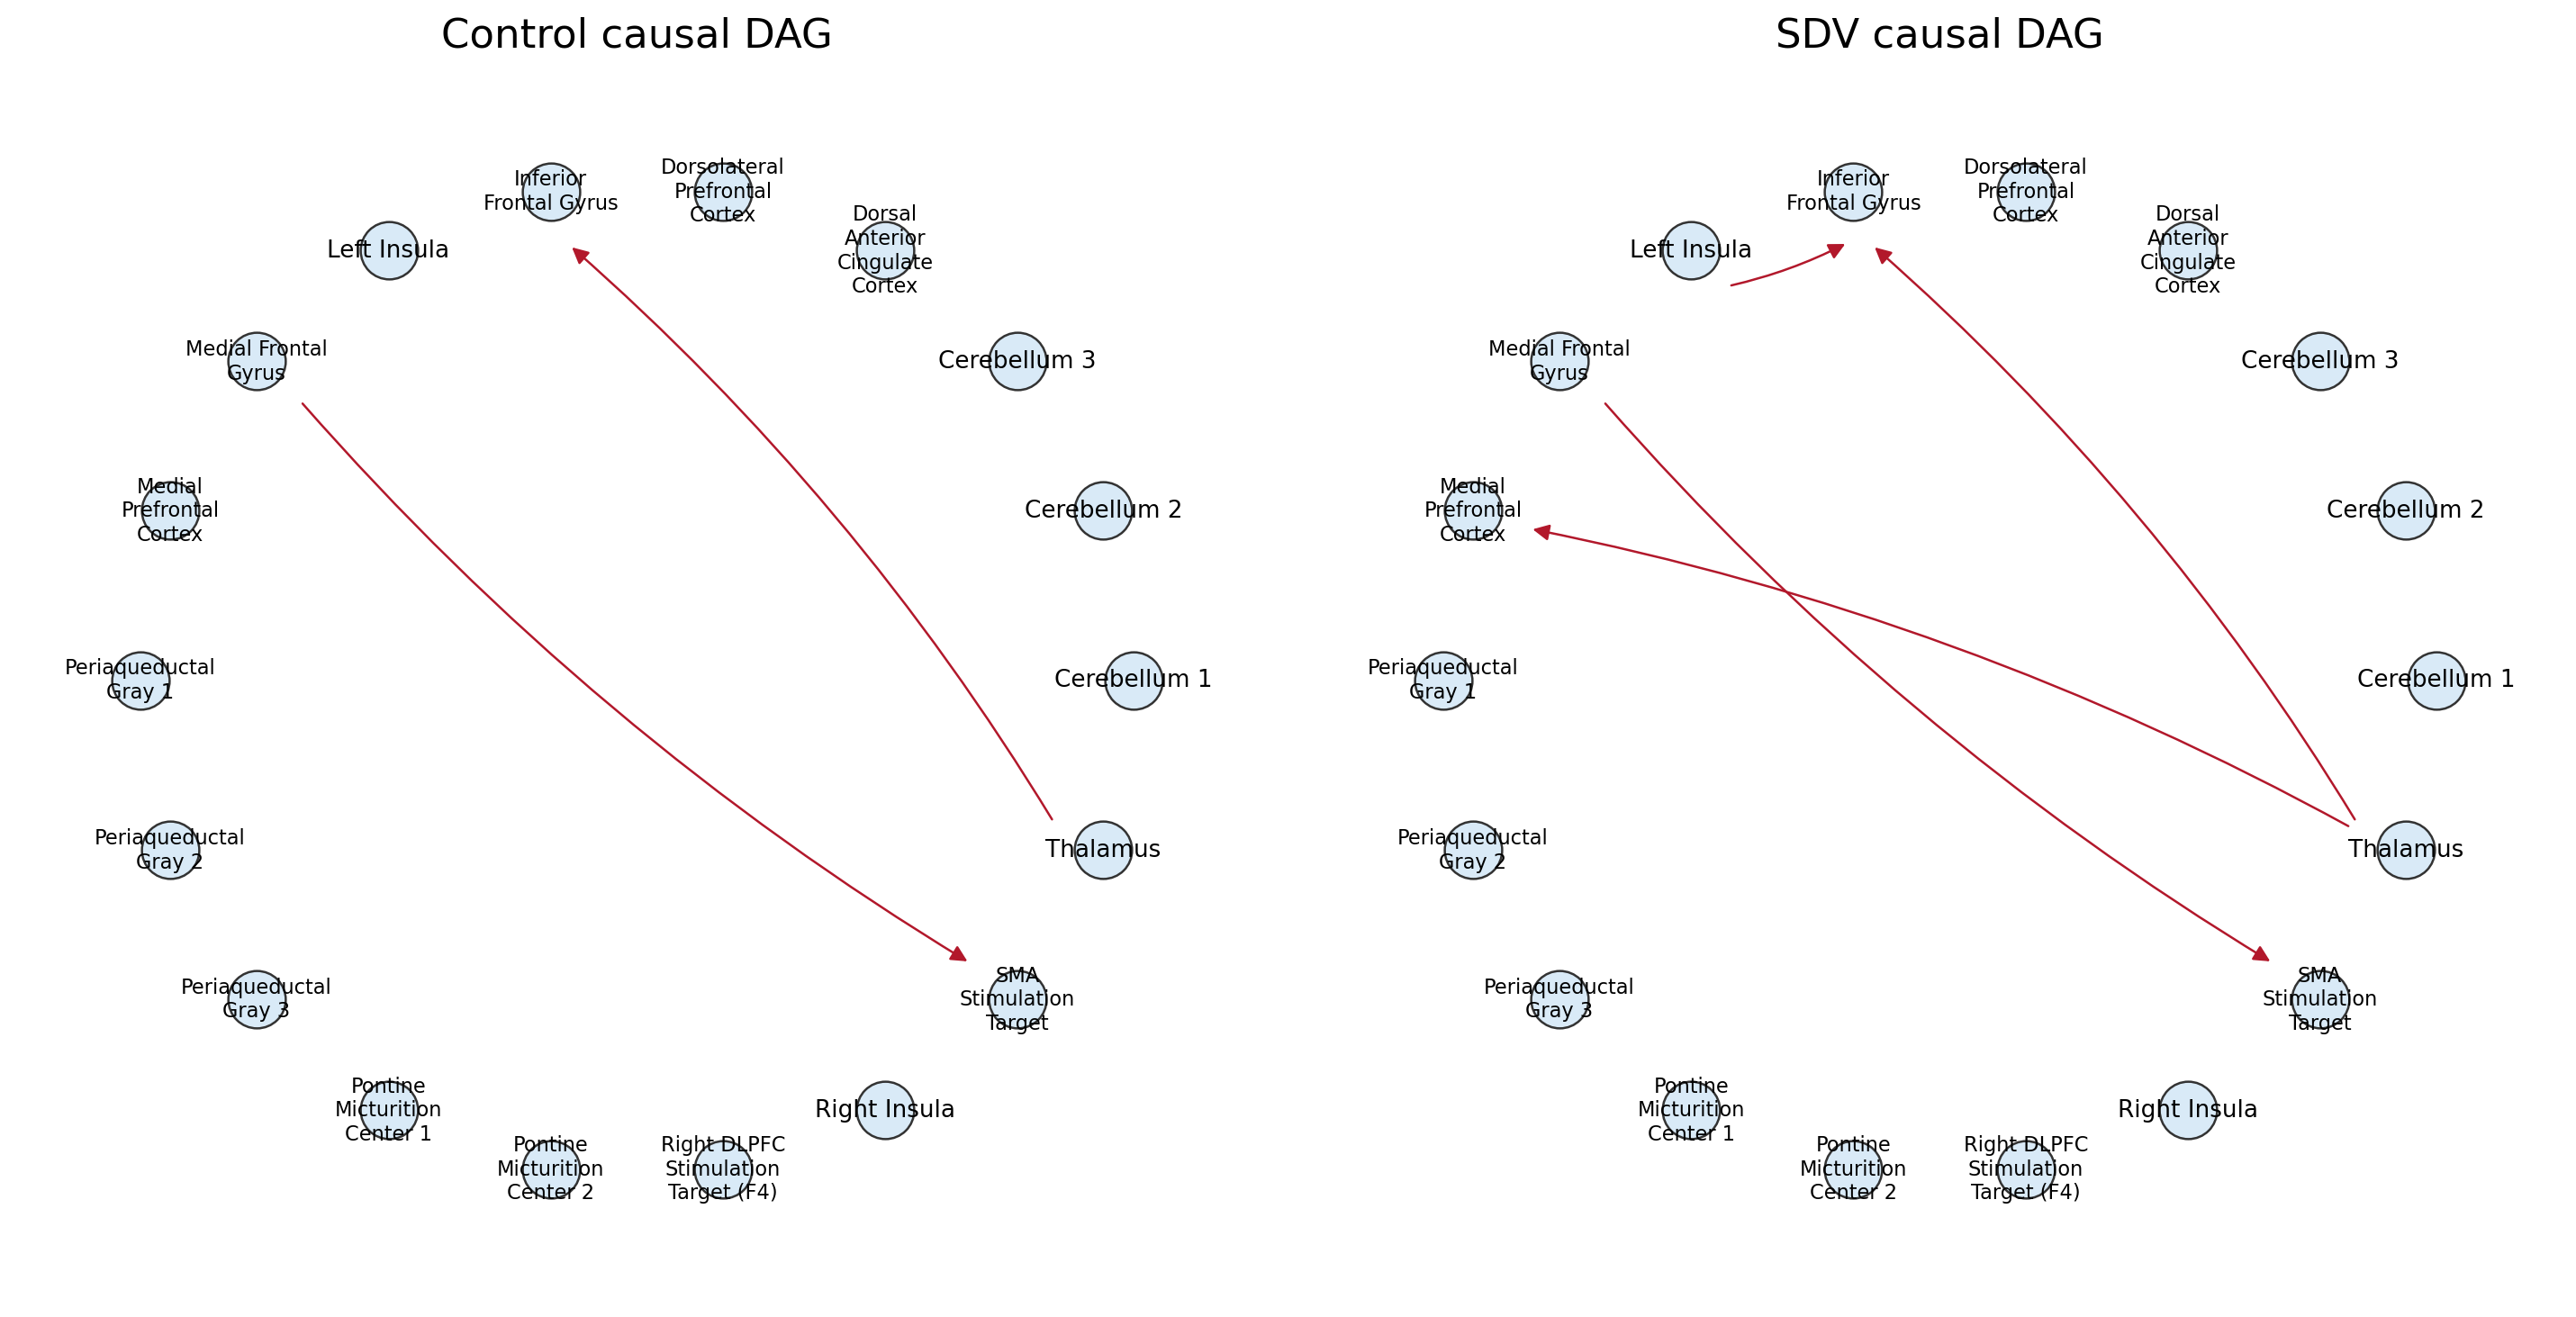

In [10]:
display_figures(plot_static_report(
    static_control, static_sdv, DISPLAY, OUTPUT, threshold=EDGE_THRESHOLD,
))

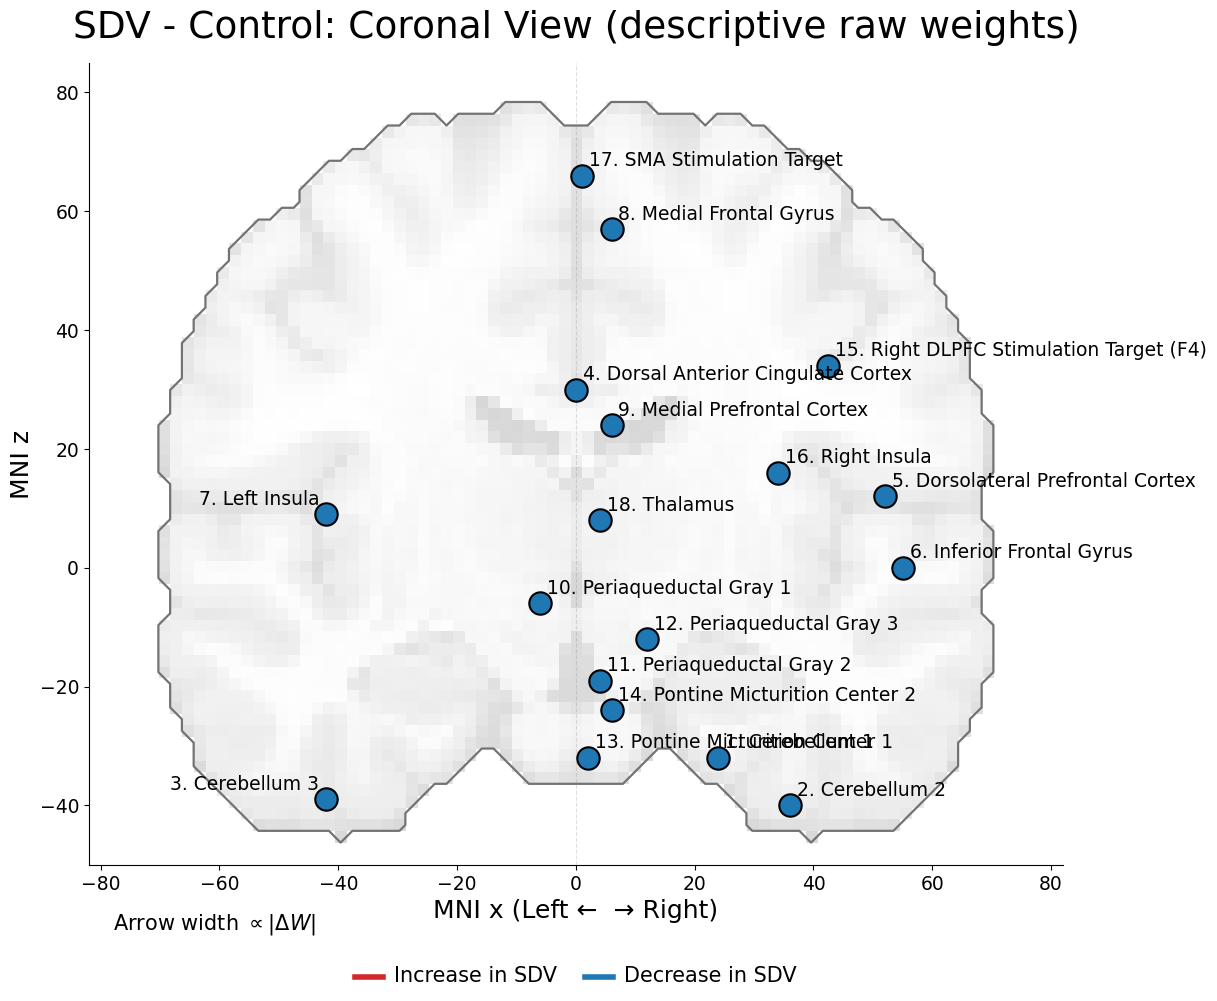

In [11]:
fig, ax = plot_anatomical_graph_difference(
    static_control.W_raw, static_sdv.W_raw, control.roi_xyz, DISPLAY,
    OUTPUT / "case2_sdv_minus_control_coronal.png",
    view="coronal", min_abs_change=EDGE_THRESHOLD,
    title="SDV - Control: Coronal View (descriptive raw weights)",
)
plt.show()
plt.close(fig)

### Optional inference, baselines, and sex analysis
The older CONN BN19 baseline, bootstrap, and sex-analysis caches belong to a different atlas and cohort. They are not loaded into this BN18 analysis. Regenerate these analyses for the same BN18 timeseries and paired subjects before attaching significance masks or interpreting cached figures. Reusable inference and sex plotting functions remain in `causal_opt.fmri_inference` and `causal_opt.fmri_plotting`.

## 4. Case 4: dynamic latent-confounded model
Pass individual subject arrays so lag construction never crosses subject boundaries.

In [ ]:
dynamic_control = fit_dynamic_latent(
    list(control.timeseries.values()), P, **DYNAMIC,
)
dynamic_sdv = fit_dynamic_latent(
    list(sdv.timeseries.values()), P, **DYNAMIC,
)
print(dynamic_control.diagnostics)
print(dynamic_sdv.diagnostics)
save_result(OUTPUT / "dynamic_control.npz", dynamic_control, DISPLAY, DISPLAY, control.subject_ids)
save_result(OUTPUT / "dynamic_sdv.npz", dynamic_sdv, DISPLAY, DISPLAY, sdv.subject_ids)

In [ ]:
display_figures(plot_dynamic_report(
    dynamic_control, dynamic_sdv, DISPLAY, OUTPUT, threshold=EDGE_THRESHOLD,
))

## 5. Descriptive changes

In [ ]:
print("Static directed changes:", top_matrix_changes(static_control.W0, static_sdv.W0, DISPLAY))
print("Static latent changes:", top_matrix_changes(
    latent_similarity(static_control), latent_similarity(static_sdv), DISPLAY,
))
print("Dynamic W0 changes:", top_matrix_changes(dynamic_control.W0, dynamic_sdv.W0, DISPLAY))
for tau in range(P):
    print(f"Lag {tau + 1} changes:", top_matrix_changes(
        dynamic_control.W_lags[tau], dynamic_sdv.W_lags[tau], DISPLAY,
    ))